# Saber Sweep v2 — 邻域细粒度搜索 (GSM8K Full)

基于 v1 结论：**`saber_exp_gl_cs_n4_mu8_bl32`** 是最佳配置（FlexAcc=0.768, NFE↓38%, Tok/s↑20%）。

本轮在该甜蜜点附近做 **n × mu × bl** 邻域搜索，共 **19 个任务**（含 anchor 重跑）。

| # | Name | n | mu | bl | 探索目的 |
|---|------|---|----|----|---------|
| 1 | dc_baseline_bl32 | — | — | 32 | baseline 对照 |
| 2 | **saber_exp_gl_cs_n4_mu8_bl32** | **4** | **8** | **32** | **anchor（v1 最佳，重跑确保同批次可比）** |
| 3 | saber_exp_gl_cs_n3_mu8_bl32 | 3 | 8 | 32 | n=3: 更保守 |
| 4 | saber_exp_gl_cs_n5_mu8_bl32 | 5 | 8 | 32 | n=5: 填补断崖 |
| 5 | saber_exp_gl_cs_n4_mu4_bl32 | 4 | 4 | 32 | mu=4: 激进 remask |
| 6 | saber_exp_gl_cs_n4_mu6_bl32 | 4 | 6 | 32 | mu=6 |
| 7 | saber_exp_gl_cs_n4_mu10_bl32 | 4 | 10 | 32 | mu=10 |
| 8 | saber_exp_gl_cs_n4_mu12_bl32 | 4 | 12 | 32 | mu=12: 保守 remask |
| 9 | saber_exp_gl_cs_n4_mu16_bl32 | 4 | 16 | 32 | mu=16 |
| 10 | saber_exp_gl_cs_n5_mu4_bl32 | 5 | 4 | 32 | n=5 + 激进 remask |
| 11 | saber_exp_gl_cs_n5_mu6_bl32 | 5 | 6 | 32 | n=5 + mu=6 |
| 12 | saber_exp_gl_cs_n5_mu10_bl32 | 5 | 10 | 32 | n=5 + mu=10 |
| 13 | saber_exp_gl_cs_n5_mu12_bl32 | 5 | 12 | 32 | n=5 + mu=12 |
| 14 | saber_exp_gl_cs_n5_mu16_bl32 | 5 | 16 | 32 | n=5 + mu=16 |
| 15 | saber_exp_gl_cs_n3_mu4_bl32 | 3 | 4 | 32 | n=3 + 激进 remask |
| 16 | saber_exp_gl_cs_n3_mu12_bl32 | 3 | 12 | 32 | n=3 + 保守 remask |
| 17 | saber_exp_gl_cs_n4_mu8_bl48 | 4 | 8 | 48 | bl=48 |
| 18 | saber_exp_gl_cs_n4_mu8_bl64 | 4 | 8 | 64 | bl=64 |
| 19 | saber_exp_gl_cs_n5_mu8_bl64 | 5 | 8 | 64 | n=5 + bl=64 |

固定参数：method=Expand, BERM=cross_step, AADU=global, saber_mtr=0.8, gen_length=256, steps=256, seed=42, 全量 GSM8K。

## 1. 环境设置

In [1]:
import os, torch, gc

os.environ['CUDA_VISIBLE_DEVICES'] = '4,5'
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
os.environ['HF_ALLOW_CODE_EVAL'] = '1'
os.environ['HF_DATASETS_TRUST_REMOTE_CODE'] = 'true'

os.chdir('llada')
os.makedirs('nlogs', exist_ok=True)

torch.cuda.empty_cache()
gc.collect()

print(f'CUDA available: {torch.cuda.is_available()}')
print(f'GPU count: {torch.cuda.device_count()}')
for i in range(torch.cuda.device_count()):
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)} '
          f'({torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB)')

CUDA available: True
GPU count: 2
  GPU 0: NVIDIA RTX A5000 (22.1 GB)
  GPU 1: NVIDIA RTX A5000 (22.1 GB)


## 2. 任务配置

In [2]:
import subprocess, datetime

task = 'gsm8k'
fewshot = 5
seed = 42
gen_length = 256
steps = 256
threshold = 0.9
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')

# v2: 18 tasks — neighborhood search around n=4, mu=8, bl=32

def _saber_exp(n, mu, bl):
    """Helper: generate extra_args for saber_expand + cross_step + global AADU."""
    return ['saber_expand=True', 'berm_mode=cross_step',
            'saber_global_aadu=True', 'saber_mtr=0.8',
            f'saber_n={n}', f'saber_mu={mu}', f'block_length={bl}']

TASK_CONFIGS = [
    # ── Baseline ───────────────────────────────────────────────────────────
    {'name': 'dc_baseline_bl32',
     'extra_args': ['use_cache=True', 'dual_cache=True',
                    f'threshold={threshold}', 'block_length=32']},

    # ── anchor (v1 最佳，重跑确保同批次可比) ────────────────────────────────
    {'name': 'saber_exp_gl_cs_n4_mu8_bl32',  'extra_args': _saber_exp(4, 8, 32)},

    # ── n sweep (mu=8, bl=32) ──────────────────────────────────────────────
    {'name': 'saber_exp_gl_cs_n3_mu8_bl32',  'extra_args': _saber_exp(3, 8, 32)},
    {'name': 'saber_exp_gl_cs_n5_mu8_bl32',  'extra_args': _saber_exp(5, 8, 32)},

    # ── mu sweep at n=4 (bl=32) ───────────────────────────────────────────
    {'name': 'saber_exp_gl_cs_n4_mu4_bl32',  'extra_args': _saber_exp(4, 4, 32)},
    {'name': 'saber_exp_gl_cs_n4_mu6_bl32',  'extra_args': _saber_exp(4, 6, 32)},
    {'name': 'saber_exp_gl_cs_n4_mu10_bl32', 'extra_args': _saber_exp(4, 10, 32)},
    {'name': 'saber_exp_gl_cs_n4_mu12_bl32', 'extra_args': _saber_exp(4, 12, 32)},
    {'name': 'saber_exp_gl_cs_n4_mu16_bl32', 'extra_args': _saber_exp(4, 16, 32)},

    # ── mu sweep at n=5 (bl=32) ───────────────────────────────────────────
    {'name': 'saber_exp_gl_cs_n5_mu4_bl32',  'extra_args': _saber_exp(5, 4, 32)},
    {'name': 'saber_exp_gl_cs_n5_mu6_bl32',  'extra_args': _saber_exp(5, 6, 32)},
    {'name': 'saber_exp_gl_cs_n5_mu10_bl32', 'extra_args': _saber_exp(5, 10, 32)},
    {'name': 'saber_exp_gl_cs_n5_mu12_bl32', 'extra_args': _saber_exp(5, 12, 32)},
    {'name': 'saber_exp_gl_cs_n5_mu16_bl32', 'extra_args': _saber_exp(5, 16, 32)},

    # ── n=3 mu corners ────────────────────────────────────────────────────
    {'name': 'saber_exp_gl_cs_n3_mu4_bl32',  'extra_args': _saber_exp(3, 4, 32)},
    {'name': 'saber_exp_gl_cs_n3_mu12_bl32', 'extra_args': _saber_exp(3, 12, 32)},

    # ── bl sweep (n=4 mu=8 / n=5 mu=8) ───────────────────────────────────
    {'name': 'saber_exp_gl_cs_n4_mu8_bl48',  'extra_args': _saber_exp(4, 8, 48)},
    {'name': 'saber_exp_gl_cs_n4_mu8_bl64',  'extra_args': _saber_exp(4, 8, 64)},
    {'name': 'saber_exp_gl_cs_n5_mu8_bl64',  'extra_args': _saber_exp(5, 8, 64)},
]

GPU_POOL = [int(x) for x in os.environ['CUDA_VISIBLE_DEVICES'].split(',')]

print(f'Total tasks: {len(TASK_CONFIGS)}  |  Available GPUs: {len(GPU_POOL)}  |  Full dataset')
print(f'Timestamp: {timestamp}')
print()
print(f'  {"Name":<38} {"n":<6} {"mu":<6} {"bl":<6}')
print('  ' + '-' * 56)
for cfg in TASK_CONFIGS:
    import re as _re
    _n  = next((a.split('=')[1] for a in cfg['extra_args'] if 'saber_n=' in a), '—')
    _mu = next((a.split('=')[1] for a in cfg['extra_args'] if 'saber_mu=' in a), '—')
    _bl_m = _re.search(r'block_length=(\d+)', ','.join(cfg['extra_args']))
    _bl = _bl_m.group(1) if _bl_m else '—'
    print(f"  {cfg['name']:<38} {_n:<6} {_mu:<6} {_bl:<6}")

Total tasks: 10  |  Available GPUs: 2  |  Full dataset
Timestamp: 20260305_163145

  Name                                   saber_n    saber_mu
  ----------------------------------------------------------
  dc_baseline_bl32                       —          —
  exp_baseline_bl64                      —          —
  saber_exp_gl_ef_n4_mu8_bl32            4          8
  saber_exp_gl_cs_n4_mu8_bl32            4          8
  saber_exp_gl_cs_n6_mu8_bl32            6          8
  saber_exp_gl_cs_n8_mu8_bl32            8          8
  saber_exp_gl_cs_n8_mu8_bl64            8          8
  saber_dc_gl_cs_n8_mu8_bl64             8          8
  saber_exp_pb_cs_n4_mu8_bl32            4          8
  saber_dc_gl_cs_n4_mu8_bl32             4          8


## 3. 并行启动任务

In [3]:
import threading, queue

task_queue = queue.Queue()
for cfg in TASK_CONFIGS:
    task_queue.put(cfg)

results_lock = threading.Lock()
all_results = []


def gpu_worker(gpu_id):
    while True:
        try:
            cfg = task_queue.get_nowait()
        except queue.Empty:
            return

        name = cfg['name']
        log_file = f'nlogs/sweep_saber_{task}_{name}_{timestamp}.log'
        output_dir = f'evals_results/saber/{task}-{name}-{timestamp}'

        common_args = [
            "model_path='GSAI-ML/LLaDA-8B-Instruct'",
            f'gen_length={gen_length}',
            f'steps={steps}',
            'show_speed=True',
            f'seed={seed}',
        ]
        model_args = ','.join(common_args + cfg['extra_args'])

        cmd = (
            f'CUDA_VISIBLE_DEVICES={gpu_id} accelerate launch eval_llada.py '
            f'--tasks {task} --num_fewshot {fewshot} '
            f'--confirm_run_unsafe_code --model llada_dist '
            f'--model_args {model_args} '
            f'--output_path {output_dir} --log_samples'
        )

        print(f'[GPU {gpu_id}] START  {name}')

        p = subprocess.Popen(
            cmd, shell=True,
            stdout=open(log_file, 'w'),
            stderr=subprocess.STDOUT,
        )
        rc = p.wait()

        status = 'OK' if rc == 0 else f'FAILED(exit={rc})'
        print(f'[GPU {gpu_id}] DONE   {name}  {status}')

        with results_lock:
            all_results.append((cfg, name, log_file, output_dir, rc))

        task_queue.task_done()


threads = []
for gpu_id in GPU_POOL:
    t = threading.Thread(target=gpu_worker, args=(gpu_id,), daemon=True)
    t.start()
    threads.append(t)

print(f'\nLaunched {len(threads)} GPU workers for {len(TASK_CONFIGS)} tasks.')
print('Waiting for all tasks to complete...')

[GPU 4] START  dc_baseline_bl32
[GPU 5] START  exp_baseline_bl64

Launched 2 GPU workers for 10 tasks.
Waiting for all tasks to complete...


In [ ]:
for t in threads:
    t.join()

print(f'\nAll {len(all_results)} / {len(TASK_CONFIGS)} tasks finished.')
for cfg, name, log_file, output_dir, rc in all_results:
    status = 'OK' if rc == 0 else f'FAILED(exit={rc})'
    print(f'  {name:30s}  {status}  log={log_file}')

## 4. 解析评测结果

In [9]:
import re, json
import pandas as pd

parsed_results = []
for cfg in TASK_CONFIGS:
    name = cfg['name']
    log_file = f'nlogs/sweep_saber_{task}_{name}_{timestamp}.log'
    if not os.path.exists(log_file):
        print(f'WARNING: {log_file} not found')
        continue
    with open(log_file, 'r') as f:
        content = f.read()

    flex_m = re.search(r'flexible-extract.*?exact_match.*?([\d.]+)', content)
    strict_m = re.search(r'strict-match.*?exact_match.*?([\d.]+)', content)
    speed_m = re.search(r'Tokens per second:\s*([\d.]+)', content)
    nfe_m = re.search(r'Total NFE is (\d+)', content)
    time_m = re.search(r'Total time taken:\s*([\d.]+)', content)
    tok_m = re.search(r'Total number of tokens generated:\s*(\d+)', content)

    _n_m  = re.search(r'_n(\d+)_', name)
    _mu_m = re.search(r'_mu(\d+)_', name)
    _bl_m = re.search(r'_bl(\d+)$', name)

    parsed_results.append({
        'name':       name,
        'n':          int(_n_m.group(1))  if _n_m  else None,
        'mu':         int(_mu_m.group(1)) if _mu_m else None,
        'bl':         int(_bl_m.group(1)) if _bl_m else None,
        'flex_acc':   float(flex_m.group(1))   if flex_m   else None,
        'strict_acc': float(strict_m.group(1)) if strict_m else None,
        'tok_per_sec':float(speed_m.group(1))  if speed_m  else None,
        'total_nfe':  int(nfe_m.group(1))      if nfe_m    else None,
        'total_tokens':int(tok_m.group(1))     if tok_m    else None,
        'time_sec':   float(time_m.group(1))   if time_m   else None,
    })

df = pd.DataFrame(parsed_results)

print(f'Saber Sweep v2 — n×mu×bl 邻域搜索 (GSM8K Full, timestamp={timestamp})')
print('=' * 112)
print(f'{"Name":<38} {"n":<4} {"mu":<5} {"bl":<5} {"FlexAcc":<10} {"StrictAcc":<11} {"Tok/s":<10} {"NFE":<10} {"Time(s)":<8}')
print('-' * 101)
for r in parsed_results:
    fa   = f"{r['flex_acc']:.4f}"    if r['flex_acc']    is not None else 'N/A'
    sa   = f"{r['strict_acc']:.4f}"  if r['strict_acc']  is not None else 'N/A'
    sp   = f"{r['tok_per_sec']:.1f}" if r['tok_per_sec'] is not None else 'N/A'
    nf   = str(r['total_nfe'])       if r['total_nfe']   is not None else 'N/A'
    tm   = f"{r['time_sec']:.1f}"    if r['time_sec']    is not None else 'N/A'
    n_s  = str(r['n'])  if r['n']  is not None else '—'
    mu_s = str(r['mu']) if r['mu'] is not None else '—'
    bl_s = str(r['bl']) if r['bl'] is not None else '—'
    print(f"{r['name']:<38} {n_s:<4} {mu_s:<5} {bl_s:<5} {fa:<10} {sa:<11} {sp:<10} {nf:<10} {tm:<8}")

display(df)

Saber Sweep (DualCache & Expand, bl=32/64) — GSM8K Full  (timestamp=20260305_163145)
Name                                 Meth   n    mu    bl    FlexAcc    Tok/s      NFE        Time(s) 
----------------------------------------------------------------------------------------------
dc_baseline_bl32                     —      —    —     32    0.7832     29.5       113011     10337.8 
exp_baseline_bl64                    —      —    —     64    0.7703     34.6       99875      8858.7  
saber_exp_gl_ef_n4_mu8_bl32          exp    4    8     32    0.7453     23.5       118460     12612.8 
saber_exp_gl_cs_n4_mu8_bl32          exp    4    8     32    0.7680     35.5       69766      8413.8  
saber_exp_gl_cs_n6_mu8_bl32          exp    6    8     32    0.6884     41.2       54038      7114.6  
saber_exp_gl_cs_n8_mu8_bl32          exp    8    8     32    0.5580     46.0       42781      6246.0  
saber_exp_gl_cs_n8_mu8_bl64          exp    8    8     64    0.6096     50.9       47772      5546.

,name,method,n,mu,bl,flex_acc,strict_acc,tok_per_sec,total_nfe,total_tokens,time_sec
0,dc_baseline_bl32,—,NaN,NaN,32,0.7832,0.3700,29.537703,113011,305354,10337.770325
1,exp_baseline_bl64,—,NaN,NaN,64,0.7703,0.3283,34.590775,99875,306428,8858.662030
2,saber_exp_gl_ef_n4_mu8_bl32,exp,4.0,8.0,32,0.7453,0.4534,23.480602,118460,296156,12612.794305
3,saber_exp_gl_cs_n4_mu8_bl32,exp,4.0,8.0,32,0.7680,0.4412,35.484776,69766,298562,8413.805517
4,saber_exp_gl_cs_n6_mu8_bl32,exp,6.0,8.0,32,0.6884,0.4018,41.183411,54038,293003,7114.587893
5,saber_exp_gl_cs_n8_mu8_bl32,exp,8.0,8.0,32,0.5580,0.3169,45.950615,42781,287008,6246.009741
6,saber_exp_gl_cs_n8_mu8_bl64,exp,8.0,8.0,64,0.6096,0.3139,50.909184,47772,282383,5546.798723
7,saber_dc_gl_cs_n8_mu8_bl64,dc,8.0,8.0,64,0.6391,0.3275,49.219662,67913,297017,6034.519471
8,saber_exp_pb_cs_n4_mu8_bl32,exp,4.0,8.0,32,0.7574,0.4321,24.066870,111675,297378,12356.322569
9,saber_dc_gl_cs_n4_mu8_bl32,dc,4.0,8.0,32,0.7483,0.3844,33.983414,95719,301077,8859.528536


## 5. 对比图：Accuracy / NFE / Speed

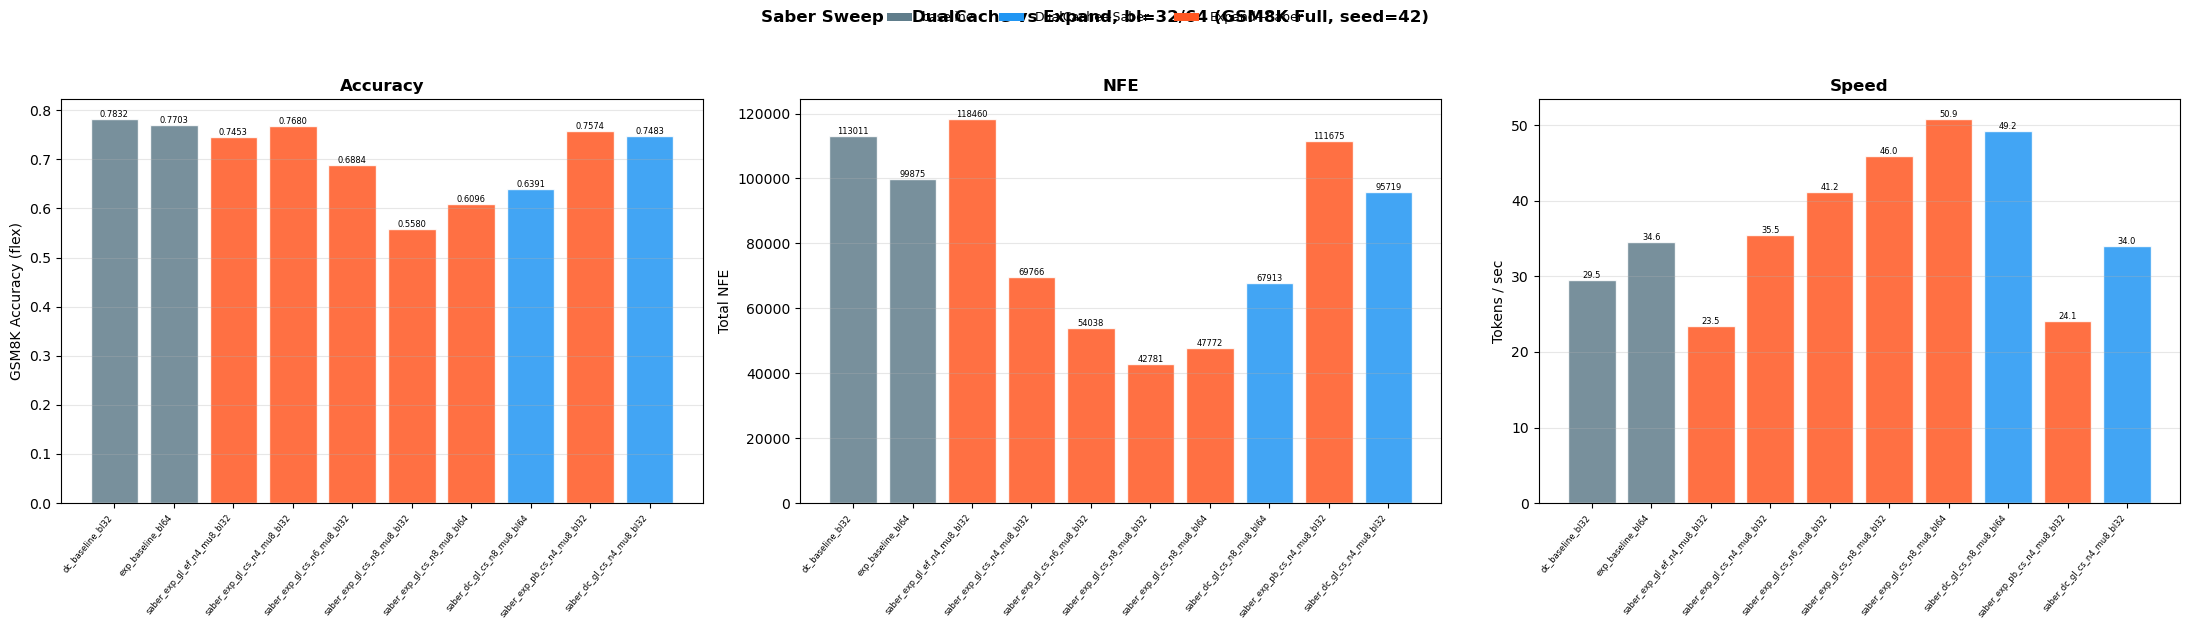

Saved: eval_results/saber_dc_exp_sweep.png


In [10]:
import matplotlib.pyplot as plt
import numpy as np

df_valid = df.dropna(subset=['flex_acc']).copy()
if df_valid.empty:
    print('No valid results to plot.')
else:
    os.makedirs('../eval_results', exist_ok=True)

    ANCHOR = 'saber_exp_gl_cs_n4_mu8_bl32'

    def _color(name):
        if 'baseline' in name: return '#607D8B'
        if name == ANCHOR: return '#E53935'
        return '#2196F3'

    colors = [_color(n) for n in df_valid['name']]
    edge_colors = ['red' if n == ANCHOR else 'white' for n in df_valid['name']]
    edge_widths = [2.5 if n == ANCHOR else 0.5 for n in df_valid['name']]

    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    metrics = [
        ('flex_acc', 'GSM8K Accuracy (flex)', 'Accuracy'),
        ('total_nfe', 'Total NFE', 'NFE'),
        ('tok_per_sec', 'Tokens / sec', 'Speed'),
    ]

    x_pos = np.arange(len(df_valid))
    names = df_valid['name'].tolist()

    for ax_idx, (col, ylabel, title) in enumerate(metrics):
        vals = df_valid[col].values
        bars = axes[ax_idx].bar(x_pos, vals, color=colors, alpha=0.85,
                                edgecolor=edge_colors, linewidth=edge_widths)
        axes[ax_idx].set_xticks(x_pos)
        axes[ax_idx].set_xticklabels(names, rotation=55, ha='right', fontsize=5.5)
        axes[ax_idx].set_ylabel(ylabel)
        axes[ax_idx].set_title(title, fontweight='bold')
        axes[ax_idx].grid(True, alpha=0.3, axis='y')
        for bar, v, nm in zip(bars, vals, names):
            if pd.notna(v):
                fmt = f'{v:.4f}' if col == 'flex_acc' else (str(int(v)) if col == 'total_nfe' else f'{v:.1f}')
                fw = 'bold' if nm == ANCHOR else 'normal'
                axes[ax_idx].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                                  fmt, ha='center', va='bottom', fontsize=5.5, fontweight=fw)
            if nm == ANCHOR:
                axes[ax_idx].text(bar.get_x() + bar.get_width()/2, 0,
                                  '★', ha='center', va='bottom', fontsize=10, color='white')

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#607D8B', label='baseline'),
        Patch(facecolor='#E53935', edgecolor='red', linewidth=2, label='★ anchor (n4 mu8 bl32)'),
        Patch(facecolor='#2196F3', label='saber variant'),
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=3, fontsize=9, frameon=False)

    fig.suptitle(f'Saber Sweep v2 — n×mu×bl 邻域搜索 (GSM8K Full, seed={seed})',
                 fontsize=12, fontweight='bold', y=1.04)
    plt.tight_layout()
    os.makedirs('../eval_results', exist_ok=True)
    plt.savefig('../eval_results/saber_v2_sweep.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: eval_results/saber_v2_sweep.png')

## 6. 从已有结果重新加载（可选）

如果 notebook 内核重启，运行此 cell 从磁盘加载已有结果（会自动检测最新 timestamp），然后重新运行 Section 5 生成图表。

In [8]:
import glob, re, json, os
import pandas as pd

task = 'gsm8k'
seed = 42

TASK_CONFIGS = [
    {'name': 'dc_baseline_bl32'},
    {'name': 'saber_exp_gl_cs_n4_mu8_bl32'},
    {'name': 'saber_exp_gl_cs_n3_mu8_bl32'},
    {'name': 'saber_exp_gl_cs_n5_mu8_bl32'},
    {'name': 'saber_exp_gl_cs_n4_mu4_bl32'},
    {'name': 'saber_exp_gl_cs_n4_mu6_bl32'},
    {'name': 'saber_exp_gl_cs_n4_mu10_bl32'},
    {'name': 'saber_exp_gl_cs_n4_mu12_bl32'},
    {'name': 'saber_exp_gl_cs_n4_mu16_bl32'},
    {'name': 'saber_exp_gl_cs_n5_mu4_bl32'},
    {'name': 'saber_exp_gl_cs_n5_mu6_bl32'},
    {'name': 'saber_exp_gl_cs_n5_mu10_bl32'},
    {'name': 'saber_exp_gl_cs_n5_mu12_bl32'},
    {'name': 'saber_exp_gl_cs_n5_mu16_bl32'},
    {'name': 'saber_exp_gl_cs_n3_mu4_bl32'},
    {'name': 'saber_exp_gl_cs_n3_mu12_bl32'},
    {'name': 'saber_exp_gl_cs_n4_mu8_bl48'},
    {'name': 'saber_exp_gl_cs_n4_mu8_bl64'},
    {'name': 'saber_exp_gl_cs_n5_mu8_bl64'},
]

first_name = TASK_CONFIGS[0]['name']
latest_logs = sorted(
    glob.glob(f'nlogs/sweep_saber_{task}_{first_name}_*.log'),
    key=os.path.getmtime, reverse=True,
)
if latest_logs:
    fname = os.path.basename(latest_logs[0])
    timestamp = fname.replace(f'sweep_saber_{task}_{first_name}_', '').replace('.log', '')
    print(f'Auto-detected latest timestamp: {timestamp}')
else:
    timestamp = 'NOTFOUND'
    print('WARNING: No log found!')

parsed_results = []
for cfg in TASK_CONFIGS:
    name = cfg['name']
    log_file = f'nlogs/sweep_saber_{task}_{name}_{timestamp}.log'
    if not os.path.exists(log_file):
        print(f'  [MISS] {name}')
        continue
    with open(log_file, 'r') as f:
        content = f.read()

    flex_m = re.search(r'flexible-extract.*?exact_match.*?([\d.]+)', content)
    strict_m = re.search(r'strict-match.*?exact_match.*?([\d.]+)', content)
    speed_m = re.search(r'Tokens per second:\s*([\d.]+)', content)
    nfe_m = re.search(r'Total NFE is (\d+)', content)
    time_m = re.search(r'Total time taken:\s*([\d.]+)', content)
    tok_m = re.search(r'Total number of tokens generated:\s*(\d+)', content)

    _n_m  = re.search(r'_n(\d+)_', name)
    _mu_m = re.search(r'_mu(\d+)_', name)
    _bl_m = re.search(r'_bl(\d+)$', name)

    parsed_results.append({
        'name': name,
        'n':          int(_n_m.group(1))  if _n_m  else None,
        'mu':         int(_mu_m.group(1)) if _mu_m else None,
        'bl':         int(_bl_m.group(1)) if _bl_m else None,
        'flex_acc': float(flex_m.group(1)) if flex_m else None,
        'strict_acc': float(strict_m.group(1)) if strict_m else None,
        'tok_per_sec': float(speed_m.group(1)) if speed_m else None,
        'total_nfe': int(nfe_m.group(1)) if nfe_m else None,
        'total_tokens': int(tok_m.group(1)) if tok_m else None,
        'time_sec': float(time_m.group(1)) if time_m else None,
    })
    print(f'  [OK]   {name}')

df = pd.DataFrame(parsed_results)
print(f'\nLoaded {len(parsed_results)} results  (seed={seed}, timestamp={timestamp})')
print(f'\n{"Name":<38} {"n":<4} {"mu":<5} {"bl":<5} {"FlexAcc":<10} {"StrictAcc":<11} {"Tok/s":<10} {"NFE":<10} {"Time(s)":<8}')
print('-' * 101)
for r in parsed_results:
    _n_m  = re.search(r'_n(\d+)_',  r['name'])
    _mu_m = re.search(r'_mu(\d+)_', r['name'])
    _bl_m = re.search(r'_bl(\d+)$', r['name'])
    n_s  = _n_m.group(1)  if _n_m  else '—'
    mu_s = _mu_m.group(1) if _mu_m else '—'
    bl_s = _bl_m.group(1) if _bl_m else '—'
    fa = f"{r['flex_acc']:.4f}"    if r['flex_acc']    is not None else 'N/A'
    sa = f"{r['strict_acc']:.4f}"  if r['strict_acc']  is not None else 'N/A'
    sp = f"{r['tok_per_sec']:.1f}" if r['tok_per_sec'] is not None else 'N/A'
    nf = str(r['total_nfe'])       if r['total_nfe']   is not None else 'N/A'
    tm = f"{r['time_sec']:.1f}"    if r['time_sec']    is not None else 'N/A'
    print(f"{r['name']:<38} {n_s:<4} {mu_s:<5} {bl_s:<5} {fa:<10} {sa:<11} {sp:<10} {nf:<10} {tm:<8}")

print(f'\nRe-run Section 5 to regenerate plots.')

Auto-detected latest timestamp: 20260305_163145
  [OK]   dc_baseline_bl32
  [OK]   exp_baseline_bl64
  [OK]   saber_exp_gl_ef_n4_mu8_bl32
  [OK]   saber_exp_gl_cs_n4_mu8_bl32
  [OK]   saber_exp_gl_cs_n6_mu8_bl32
  [OK]   saber_exp_gl_cs_n8_mu8_bl32
  [OK]   saber_exp_gl_cs_n8_mu8_bl64
  [OK]   saber_dc_gl_cs_n8_mu8_bl64
  [OK]   saber_exp_pb_cs_n4_mu8_bl32
  [OK]   saber_dc_gl_cs_n4_mu8_bl32

Loaded 10 results  (seed=42, timestamp=20260305_163145)

Name                                 Meth   n    mu    bl    FlexAcc    Tok/s      NFE        Time(s) 
----------------------------------------------------------------------------------------------
dc_baseline_bl32                     —      —    —     32    0.7832     29.5       113011     10337.8 
exp_baseline_bl64                    —      —    —     64    0.7703     34.6       99875      8858.7  
saber_exp_gl_ef_n4_mu8_bl32          exp    4    8     32    0.7453     23.5       118460     12612.8 
saber_exp_gl_cs_n4_mu8_bl32          exp